# Case study

**Aim**: Illustrate the main analysis steps in the rifampicin pilot study on a single case. 

**Requirements**: Before running this notebook, make sure to install all required packages:

```console
pip install -r requirements.txt
```

This script analyses a single case from one of the human studies:

In [ ]:
DRUG = 'ciclosporin'
PARTICIPANT = 'SHF-006'

## Model definition

We first define a function that returns a trained tissue model:

In [ ]:
import numpy as np
import dcmri as dc

def subject_model(pars, rois):

    # Get time arrays
    time_1 = rois['time_1'] - rois['time_1'][0]
    time_2 = rois['time_2'] - rois['time_1'][0]

    # Define default model
    model = dc.AortaLiver2scan(

        # Configuration
        kinetics='1I-IC-HFD', 
        non_stationary='UE', 
        sequence='SS', 

        # Parameters
        dt = 0.5,
        tmax = max(time_2),
        dose_tolerance = 0.1,
        field_strength = 3.0,

        # Injection parameters
        weight=pars['weight'],
        agent='gadoxetate',
        dose=pars['dose_1'],
        rate=1.0,
        dose2=pars['dose_2'],

        # Acquisition parameters
        TR=pars['TR'], 
        FA=pars['FA_1'],
        FA2=pars['FA_2'],
        TS = np.min(time_1[1:] - time_1[:-1]),
        
        # Signal parameters
        R10a=1/pars['T1_aorta_1'],
        R10l=1/pars['T1_liver_1'],

        # Tissue parameters
        H=0.45,
        vol=pars['liver_volume'],

        # Aorta parameters
        BAT2=1200,
        BAT=60,
        CO=100,
        Thl=10,
        Dhl=0.2,
        To=20,
        Eo=0.15,
        Toe=120,
        Eb=0.05,

        # Liver parameters
        Tg=30,
        Dg=0.85,
        ve=0.3,
        khe_i=0.003,
        khe_f=0.003,
        Th_i=30*60,
        Th_f=30*60,
    )

    # Get data at valid (accepted) time points
    xdata = (
        time_1[rois['aorta_1_accept']], 
        time_2[rois['aorta_2_accept']], 
        time_1[rois['liver_1_accept']],
        time_2[rois['liver_2_accept']],
    )
    ydata = (
        rois['aorta_1'][rois['aorta_1_accept']],
        rois['aorta_2'][rois['aorta_2_accept']],
        rois['liver_1'][rois['liver_1_accept']],
        rois['liver_2'][rois['liver_2_accept']],
    )

    # Train the model to the data
    model.train(
        xdata, 
        ydata, 
        n0=max([np.sum(xdata[0] < pars['t0']), 2]), 
        R102a=1/pars['T1_aorta_3'],
        R102l=1/pars['T1_liver_3'],
        joint=True,
        xtol=1e-3, 
        verbose=0,
        free = {
            'S02a': [0.5, 1.5],
            'S02l': [0.5, 1.5],
            
            'BAT2': [-30, 30],
            'BAT': [-30, 30],
            'CO': [0, 300],
            'Thl': [0, 30],
            'Dhl': [0.05, 0.95],
            'To': [0, 60],
            'Eo': [0, 0.5],
            'Toe': [0, 800],
            'Eb': [0.01, 0.15],

            've': [0.01, 0.6],
            'Tg': [0.1, 60], 
            'Dg': [0, 1],
            'khe_i': [0, 0.03],
            'khe_f': [0, 0.03],
            'Th_i': [10*60, 10*60*60],
            'Th_f': [10*60, 10*60*60],
        }
    )

    # Return the model and data
    return model, xdata, ydata


## Case study

In [3]:
import os
import miblab
import pydmr


# Define paths
repo_dir = os.getcwd()
data_folder = os.path.join(repo_dir, 'data')
build_folder = os.path.join(repo_dir, 'build')
os.makedirs(build_folder, exist_ok=True)

# Download and read the data
dataset = f'tristan_humans_healthy_{DRUG}.dmr.zip'
datafile = miblab.zenodo_fetch(dataset, data_folder)
data = pydmr.read(datafile, format='nest')


In [4]:
# Train a model to control data

VISIT = 'control'
pars = data['pars'][PARTICIPANT][VISIT]
rois = data['rois'][PARTICIPANT][VISIT]
model_control, x_control, y_control = subject_model(pars, rois)

In [5]:
# Train a model to treatment data

VISIT = 'drug'
pars = data['pars'][PARTICIPANT][VISIT]
rois = data['rois'][PARTICIPANT][VISIT]
model_drug, x_drug, y_drug = subject_model(pars, rois)

In [6]:
# Determine effect sizes

khe_control = 6000* model_control.params('khe')
khe_drug = 6000 * model_drug.params('khe')
khe_effect = 100 * (khe_drug - khe_control) / khe_control

kbh_control = 6000 * model_control.params('kbh')
kbh_drug = 6000 * model_drug.params('kbh')
kbh_effect = 100 * (kbh_drug - kbh_control) / kbh_control

# Print effect sizes
print(f'khe: {khe_control:.1f} -> {khe_drug:.1f} mL/min/100cm3 ({khe_effect:.1f} %)')
print(f'kbh: {kbh_control:.2f} -> {kbh_drug:.2f} mL/min/100cm3 ({kbh_effect:.1f} %)')

khe: 91.1 -> 3.7 mL/min/100cm3 (-95.9 %)
kbh: 3.84 -> 1.31 mL/min/100cm3 (-65.8 %)


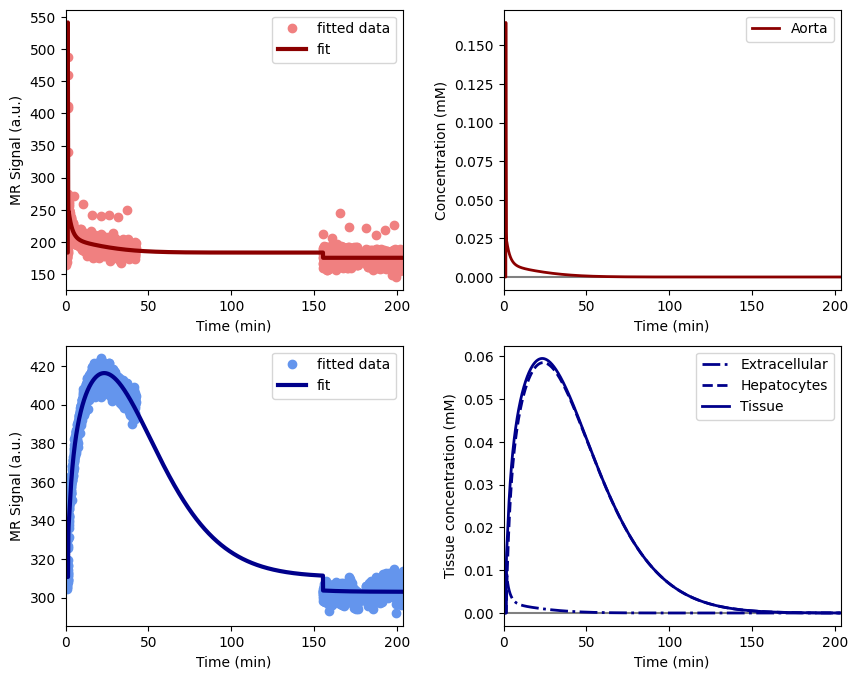

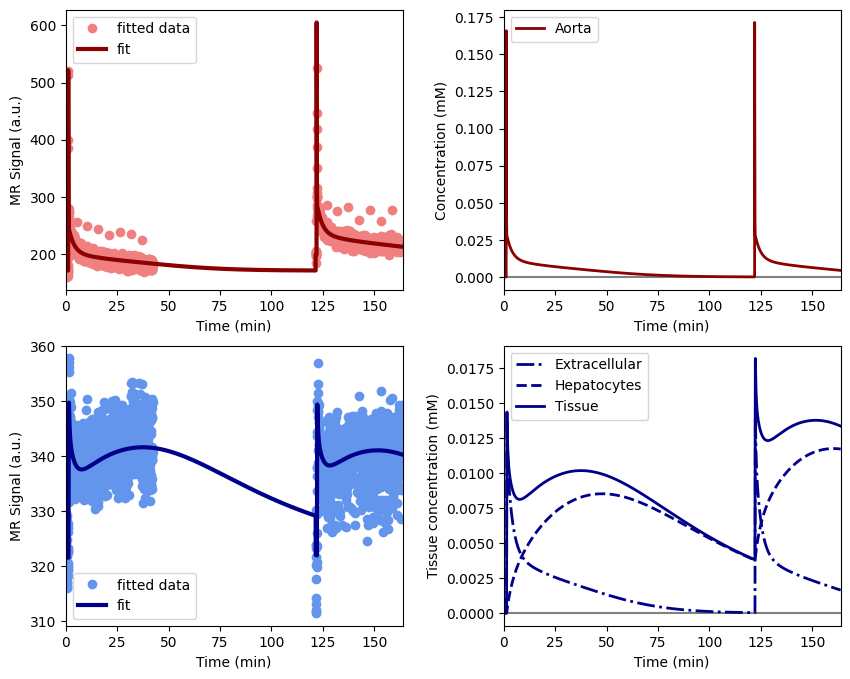

In [7]:
# Check the model fits

model_control.plot(x_control, y_control)
model_drug.plot(x_drug, y_drug)

In [8]:
# Print all the other parameters

print('\n')
print('==================')
print('Control parameters')
print('==================')

model_control.print_params(round_to=5)

print('\n')
print('====================')
print('Treatment parameters')
print('====================')

model_drug.print_params(round_to=5)



Control parameters

--------------------------------
Free parameters with their stdev
--------------------------------

Aorta second signal scale factor (S02a): 11049.15465 (12.6979) a.u.
Liver second signal scale factor (S02l): 8753.55681 (10.55358) a.u.
Second bolus arrival time (BAT2): 109286.65585 (0.0) sec
First bolus arrival time (BAT): 65.91368 (1.41897) sec
Cardiac output (CO): 90.01935 (2.59843) mL/sec
Heart-lung mean transit time (Thl): 19.77073 (1.6469) sec
Heart-lung dispersion (Dhl): 0.39431 (0.02901) 
Organs blood mean transit time (To): 27.79957 (1.94285) sec
Organs extraction fraction (Eo): 0.15769 (0.01201) 
Organs extravascular mean transit time (Toe): 309.03825 (27.26955) sec
Body extraction fraction (Eb): 0.09121 (0.00399) 
Gut mean transit time (Tg): 31.43619 (16.71745) sec
Gut dispersion (Dg): 0.71837 (0.1687) 
Liver extracellular volume fraction (ve): 0.16189 (0.08737) mL/cm3
Initial hepatocellular uptake rate (khe_i): 0.00796 (0.00034) mL/sec/cm3
Final hepatoc